<a href="https://colab.research.google.com/github/chirag1503/portfolio_risklan/blob/main/Portfolio_RiskLab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip -q install yfinance pandas numpy matplotlib

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from datetime import date, timedelta

pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", "{:,.4f}".format)

print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
stocks = [
    "RELIANCE.NS",
    "TCS.NS",
    "INFY.NS",
    "HDFCBANK.NS",
    "ICICIBANK.NS",
    "SBIN.NS",
    "ITC.NS",
    "LT.NS",
    "BHARTIARTL.NS",
    "SUNPHARMA.NS"
]

benchmark = "^NSEI"

tickers = stocks + [benchmark]

# Approximately five years of history
end_date = date.today()
start_date = end_date - timedelta(days=5 * 365 + 5)

print("Number of stock tickers:", len(stocks))
print("Benchmark:", benchmark)
print("Start date:", start_date)
print("End date:", end_date)

Number of stock tickers: 10
Benchmark: ^NSEI
Start date: 2021-09-24
End date: 2026-09-28


In [ ]:
raw_data = yf.download(tickers, start=start_date, end=end_date)

# With multiple tickers, yfinance returns a MultiIndex column structure.
prices = raw_data["Close"].copy()

# Remove duplicate dates, if any, and sort chronologically.
prices = prices[~prices.index.duplicated(keep="first")]
prices = prices.sort_index()

print("Closing-price data shape:", prices.shape)
display(prices.head())

/tmp/ipykernel_3425/3951524403.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw_data = yf.download(tickers, start=start_date, end=end_date)
[*********************100%***********************]  11 of 11 completed

Closing-price data shape: (1242, 11)


Ticker,BHARTIARTL.NS,HDFCBANK.NS,ICICIBANK.NS,INFY.NS,ITC.NS,LT.NS,RELIANCE.NS,SBIN.NS,SUNPHARMA.NS,TCS.NS,^NSEI
Date,,,,,,,,,,,
2021-09-24,700.5257,749.3632,695.4130,"1,536.2648",187.7532,"1,681.0211","1,124.4594",403.1748,733.3248,"3,362.9922","17,853.1992"
2021-09-27,697.4142,760.3823,702.1944,"1,499.0742",187.9500,"1,653.3168","1,143.3687",408.5261,726.2814,"3,333.1523","17,855.0996"
2021-09-28,671.9326,755.6798,689.8339,"1,469.4176",187.2020,"1,650.9883","1,154.0574",406.9710,737.7507,"3,282.9417","17,748.5996"
2021-09-29,669.9539,745.7603,682.4753,"1,473.9032",187.4776,"1,635.6395","1,144.9087",420.7837,772.2064,"3,294.0178","17,711.3008"
2021-09-30,664.3558,746.2750,674.1547,"1,459.0531",185.9422,"1,618.4847","1,141.0133",414.3805,778.8214,"3,279.8147","17,618.1504"


In [ ]:
print("Downloaded tickers:")
print(prices.columns.tolist())

print("\nDate range:")
print("First date:", prices.index.min())
print("Last date:", prices.index.max())

print("\nMissing values by ticker:")
display(prices.isna().sum().to_frame("missing_values"))

print("\nDuplicate dates:", prices.index.duplicated().sum())

Downloaded tickers:
['BHARTIARTL.NS', 'HDFCBANK.NS', 'ICICIBANK.NS', 'INFY.NS', 'ITC.NS', 'LT.NS', 'RELIANCE.NS', 'SBIN.NS', 'SUNPHARMA.NS', 'TCS.NS', '^NSEI']

Date range:
First date: 2021-09-24 00:00:00
Last date: 2026-09-25 00:00:00

Missing values by ticker:


,missing_values
Ticker,
BHARTIARTL.NS,0
HDFCBANK.NS,0
ICICIBANK.NS,0
INFY.NS,0
ITC.NS,0
LT.NS,0
RELIANCE.NS,0
SBIN.NS,0
SUNPHARMA.NS,0



Duplicate dates: 0


In [ ]:
# Remove columns with no downloaded price data.
prices = prices.dropna(axis=1, how="all")

# Remove dates where all tickers have missing values.
prices = prices.dropna(axis=0, how="all")

# Confirm the benchmark was downloaded.
if benchmark not in prices.columns:
    raise ValueError(
        f"Benchmark {benchmark} was not downloaded. "
        "Check the ticker or try downloading it separately."
    )

print("Cleaned data shape:", prices.shape)
print("Available tickers:", prices.columns.tolist())

display(prices.tail())

Cleaned data shape: (1242, 11)
Available tickers: ['BHARTIARTL.NS', 'HDFCBANK.NS', 'ICICIBANK.NS', 'INFY.NS', 'ITC.NS', 'LT.NS', 'RELIANCE.NS', 'SBIN.NS', 'SUNPHARMA.NS', 'TCS.NS', '^NSEI']


Ticker,BHARTIARTL.NS,HDFCBANK.NS,ICICIBANK.NS,INFY.NS,ITC.NS,LT.NS,RELIANCE.NS,SBIN.NS,SUNPHARMA.NS,TCS.NS,^NSEI
Date,,,,,,,,,,,
2026-09-21,"1,830.2000",739.5000,"1,345.0000","1,038.5000",267.0000,"3,904.8000","1,247.4000",996.0000,"1,868.9000","2,128.7000","23,414.3008"
2026-09-22,"1,817.2000",738.6000,"1,339.6000","1,029.4000",265.8000,"3,866.3999","1,240.4000",987.0000,"1,846.4000","2,105.0000","23,329.0000"
2026-09-23,"1,833.2000",737.2500,"1,340.0000","1,020.5000",270.1500,"3,929.8999","1,248.0000",994.1000,"1,865.0000","2,089.6001","23,446.8008"
2026-09-24,"1,795.8000",728.9000,"1,334.5000","1,014.5000",268.0000,"3,858.3999","1,219.2000",978.5000,"1,849.9000","2,087.0000","23,063.0996"
2026-09-25,"1,785.4000",735.6000,"1,326.8000","1,000.2000",269.0000,"3,876.2000","1,226.0000",983.0000,"1,852.2000","2,082.0000","23,140.5000"


In [ ]:
prices.to_csv("adjusted_closing_prices.csv")

print("Saved: adjusted_closing_prices.csv")

Saved: adjusted_closing_prices.csv


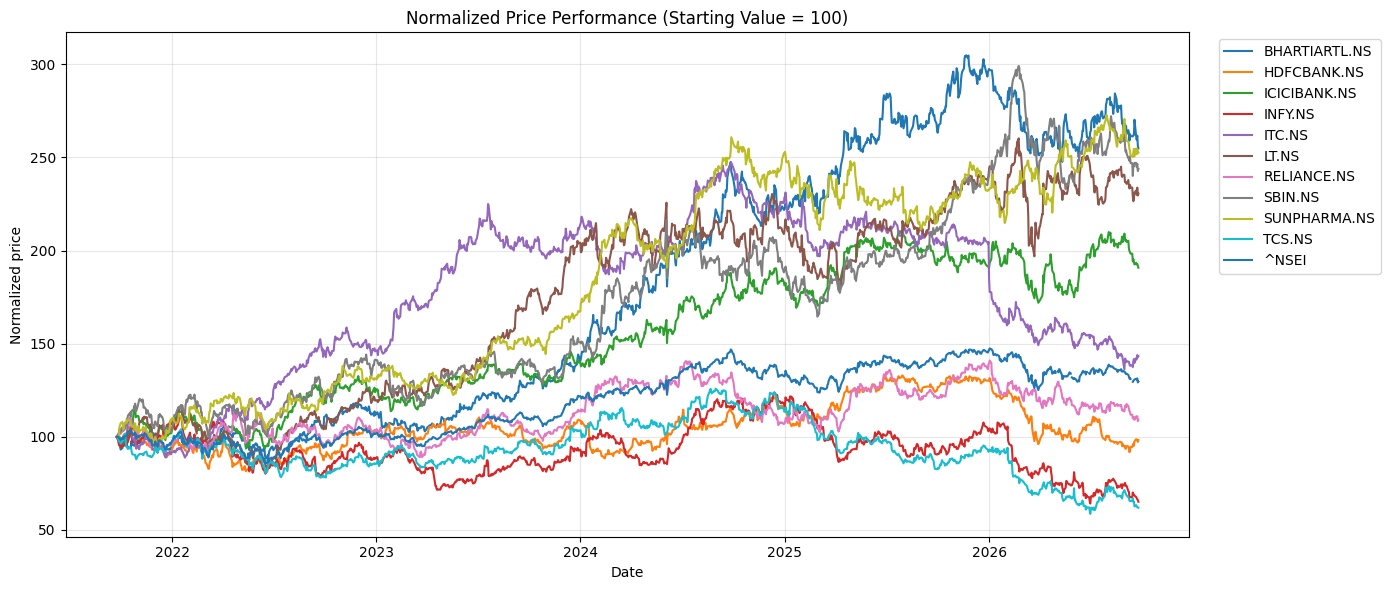

In [ ]:
normalized_prices = prices / prices.iloc[0] * 100

plt.figure(figsize=(14, 6))

for ticker in normalized_prices.columns:
    plt.plot(
        normalized_prices.index,
        normalized_prices[ticker],
        label=ticker
    )

plt.title("Normalized Price Performance (Starting Value = 100)")
plt.xlabel("Date")
plt.ylabel("Normalized price")
plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
daily_returns = prices.pct_change(fill_method=None)
log_returns = np.log(prices / prices.shift(1))

# Drop the first row, which has no previous-day return.
daily_returns = daily_returns.dropna(how="all")
log_returns = log_returns.dropna(how="all")

print("Daily returns:")
display(daily_returns.head())

print("Log returns:")
display(log_returns.head())

Daily returns:


Ticker,BHARTIARTL.NS,HDFCBANK.NS,ICICIBANK.NS,INFY.NS,ITC.NS,LT.NS,RELIANCE.NS,SBIN.NS,SUNPHARMA.NS,TCS.NS,^NSEI
Date,,,,,,,,,,,
2021-09-27,-0.0044,0.0147,0.0098,-0.0242,0.0010,-0.0165,0.0168,0.0133,-0.0096,-0.0089,0.0001
2021-09-28,-0.0365,-0.0062,-0.0176,-0.0198,-0.0040,-0.0014,0.0093,-0.0038,0.0158,-0.0151,-0.0060
2021-09-29,-0.0029,-0.0131,-0.0107,0.0031,0.0015,-0.0093,-0.0079,0.0339,0.0467,0.0034,-0.0021
2021-09-30,-0.0084,0.0007,-0.0122,-0.0101,-0.0082,-0.0105,-0.0034,-0.0152,0.0086,-0.0043,-0.0053
2021-10-01,-0.0180,-0.0077,-0.0121,-0.0060,-0.0034,-0.0036,0.0018,-0.0030,0.0102,-0.0120,-0.0049


Log returns:


Ticker,BHARTIARTL.NS,HDFCBANK.NS,ICICIBANK.NS,INFY.NS,ITC.NS,LT.NS,RELIANCE.NS,SBIN.NS,SUNPHARMA.NS,TCS.NS,^NSEI
Date,,,,,,,,,,,
2021-09-27,-0.0045,0.0146,0.0097,-0.0245,0.0010,-0.0166,0.0167,0.0132,-0.0097,-0.0089,0.0001
2021-09-28,-0.0372,-0.0062,-0.0178,-0.0200,-0.0040,-0.0014,0.0093,-0.0038,0.0157,-0.0152,-0.0060
2021-09-29,-0.0029,-0.0132,-0.0107,0.0030,0.0015,-0.0093,-0.0080,0.0334,0.0456,0.0034,-0.0021
2021-09-30,-0.0084,0.0007,-0.0123,-0.0101,-0.0082,-0.0105,-0.0034,-0.0153,0.0085,-0.0043,-0.0053
2021-10-01,-0.0182,-0.0077,-0.0122,-0.0060,-0.0034,-0.0036,0.0018,-0.0030,0.0102,-0.0121,-0.0049


In [ ]:
return_summary = pd.DataFrame({
    "Mean Daily Return": daily_returns.mean(),
    "Daily Std Dev": daily_returns.std(),
    "Minimum Daily Return": daily_returns.min(),
    "Maximum Daily Return": daily_returns.max(),
    "Observations": daily_returns.count()
})

display(return_summary.sort_values("Daily Std Dev", ascending=False))

,Mean Daily Return,Daily Std Dev,Minimum Daily Return,Maximum Daily Return,Observations
Ticker,,,,,
INFY.NS,-0.0002,0.0164,-0.0942,0.0793,1241
SBIN.NS,0.0008,0.0154,-0.1440,0.0907,1241
LT.NS,0.0008,0.0154,-0.1267,0.0759,1241
TCS.NS,-0.0003,0.0142,-0.0839,0.0663,1241
RELIANCE.NS,0.0002,0.0140,-0.0749,0.0702,1241
BHARTIARTL.NS,0.0008,0.0135,-0.0657,0.0527,1241
HDFCBANK.NS,0.0001,0.0132,-0.0844,0.1001,1241
ICICIBANK.NS,0.0006,0.0127,-0.0763,0.1085,1241
SUNPHARMA.NS,0.0008,0.0126,-0.0455,0.0698,1241


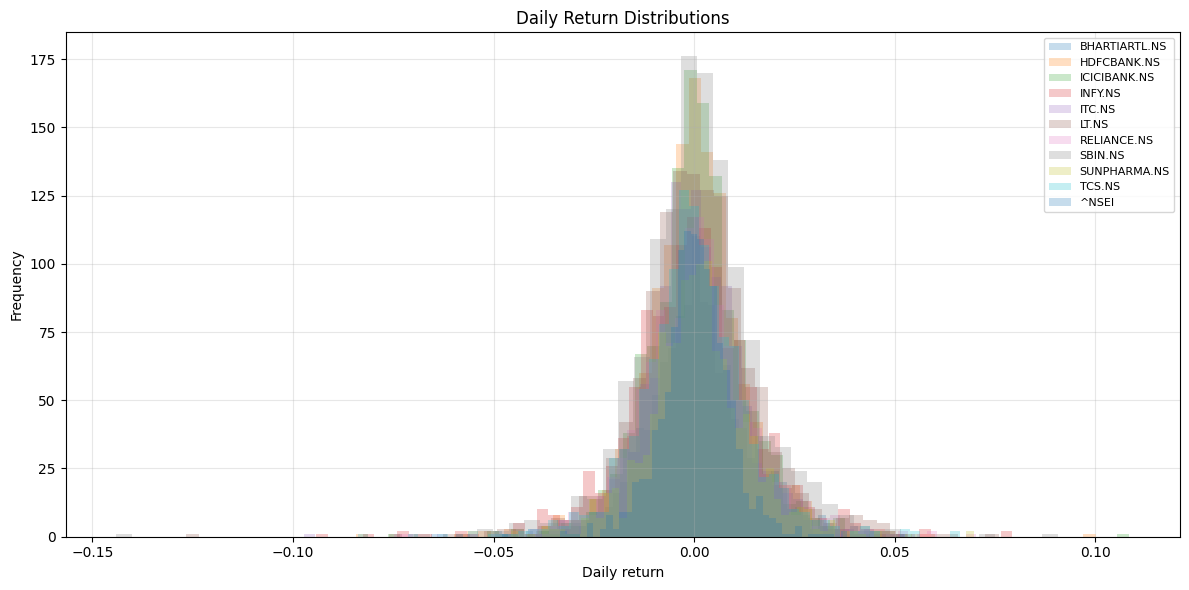

In [ ]:
plt.figure(figsize=(12, 6))

for ticker in daily_returns.columns:
    plt.hist(
        daily_returns[ticker].dropna(),
        bins=60,
        alpha=0.25,
        label=ticker
    )

plt.title("Daily Return Distributions")
plt.xlabel("Daily return")
plt.ylabel("Frequency")
plt.legend(loc="upper right", fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
TRADING_DAYS = 252

annualized_volatility = daily_returns.std() * np.sqrt(TRADING_DAYS)

volatility_table = (
    annualized_volatility
    .sort_values(ascending=False)
    .to_frame("Annualized Volatility")
)

display(volatility_table)

,Annualized Volatility
Ticker,
INFY.NS,0.2598
SBIN.NS,0.2450
LT.NS,0.2438
TCS.NS,0.2258
RELIANCE.NS,0.2227
BHARTIARTL.NS,0.2148
HDFCBANK.NS,0.2094
ICICIBANK.NS,0.2015
SUNPHARMA.NS,0.2004


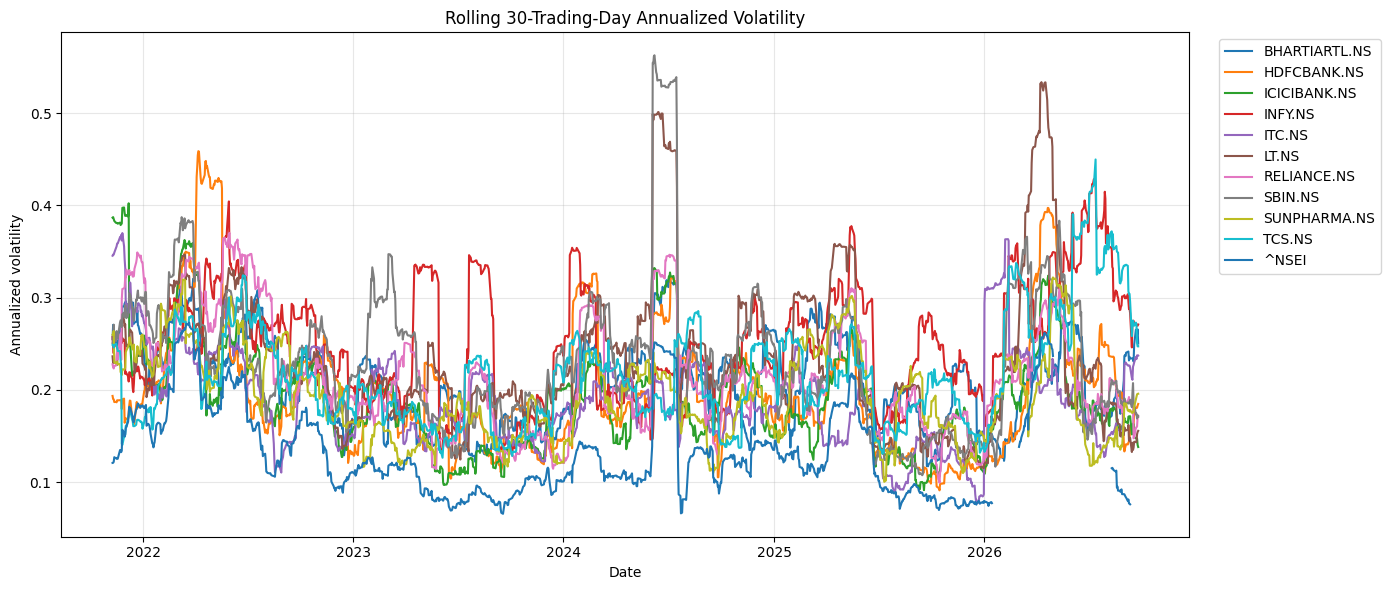

In [ ]:
rolling_volatility_30d = (
    daily_returns
    .rolling(window=30)
    .std()
    * np.sqrt(TRADING_DAYS)
)

plt.figure(figsize=(14, 6))

for ticker in rolling_volatility_30d.columns:
    plt.plot(
        rolling_volatility_30d.index,
        rolling_volatility_30d[ticker],
        label=ticker
    )

plt.title("Rolling 30-Trading-Day Annualized Volatility")
plt.xlabel("Date")
plt.ylabel("Annualized volatility")
plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
correlation_matrix = daily_returns.corr()

display(correlation_matrix.round(2))

Ticker,BHARTIARTL.NS,HDFCBANK.NS,ICICIBANK.NS,INFY.NS,ITC.NS,LT.NS,RELIANCE.NS,SBIN.NS,SUNPHARMA.NS,TCS.NS,^NSEI
Ticker,,,,,,,,,,,
BHARTIARTL.NS,1.0000,0.2800,0.3200,0.2500,0.2400,0.2900,0.3300,0.2800,0.2300,0.2000,0.5100
HDFCBANK.NS,0.2800,1.0000,0.4900,0.2500,0.2300,0.4100,0.3700,0.4100,0.1600,0.2300,0.7000
ICICIBANK.NS,0.3200,0.4900,1.0000,0.2300,0.2600,0.4100,0.3400,0.5100,0.2100,0.2100,0.6600
INFY.NS,0.2500,0.2500,0.2300,1.0000,0.1900,0.3000,0.2600,0.1800,0.1900,0.7300,0.5200
ITC.NS,0.2400,0.2300,0.2600,0.1900,1.0000,0.2600,0.3100,0.2700,0.2100,0.1800,0.4600
LT.NS,0.2900,0.4100,0.4100,0.3000,0.2600,1.0000,0.4300,0.4600,0.2500,0.3000,0.6700
RELIANCE.NS,0.3300,0.3700,0.3400,0.2600,0.3100,0.4300,1.0000,0.4300,0.2600,0.2700,0.6900
SBIN.NS,0.2800,0.4100,0.5100,0.1800,0.2700,0.4600,0.4300,1.0000,0.1700,0.1900,0.6500
SUNPHARMA.NS,0.2300,0.1600,0.2100,0.1900,0.2100,0.2500,0.2600,0.1700,1.0000,0.2200,0.3800


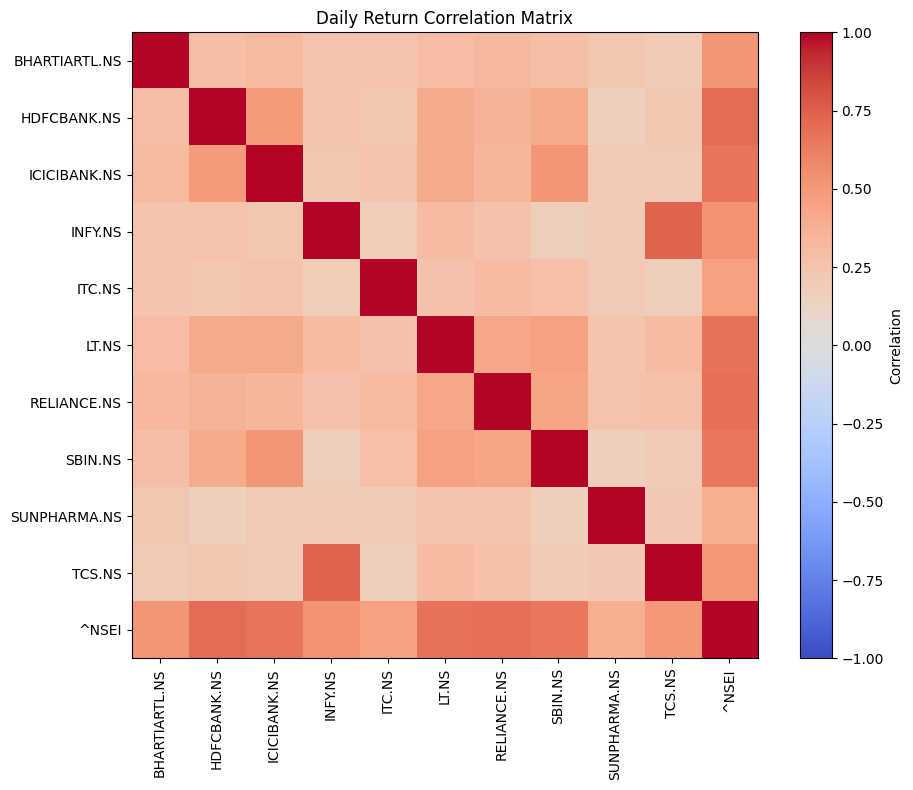

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))

image = ax.imshow(
    correlation_matrix,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

ax.set_xticks(range(len(correlation_matrix.columns)))
ax.set_yticks(range(len(correlation_matrix.index)))

ax.set_xticklabels(correlation_matrix.columns, rotation=90)
ax.set_yticklabels(correlation_matrix.index)

ax.set_title("Daily Return Correlation Matrix")

fig.colorbar(image, ax=ax, label="Correlation")
plt.tight_layout()
plt.show()

In [ ]:
benchmark_correlations = (
    daily_returns
    .corr()[benchmark]
    .drop(index=benchmark)
    .sort_values(ascending=False)
)

display(
    benchmark_correlations.to_frame(
        "Correlation with NIFTY 50"
    )
)

,Correlation with NIFTY 50
Ticker,
HDFCBANK.NS,0.6990
RELIANCE.NS,0.6862
LT.NS,0.6743
ICICIBANK.NS,0.6614
SBIN.NS,0.6519
INFY.NS,0.5236
BHARTIARTL.NS,0.5107
TCS.NS,0.5005
ITC.NS,0.4575


In [ ]:
daily_returns.to_csv("daily_returns.csv")
log_returns.to_csv("log_returns.csv")
correlation_matrix.to_csv("correlation_matrix.csv")
rolling_volatility_30d.to_csv("rolling_30d_volatility.csv")

print("Saved Day 2 CSV outputs.")

Saved Day 2 CSV outputs.


In [ ]:
# Confirm the stock list and benchmark exist in our downloaded data.

available_tickers = prices.columns.tolist()

portfolio_stocks = [
    ticker for ticker in stocks
    if ticker in available_tickers
]

missing_stocks = [
    ticker for ticker in stocks
    if ticker not in available_tickers
]

print("Stocks included:", portfolio_stocks)
print("Missing stocks:", missing_stocks)
print("Benchmark available:", benchmark in available_tickers)

if len(portfolio_stocks) == 0:
    raise ValueError("No portfolio stocks are available in the price data.")

if benchmark not in available_tickers:
    raise ValueError("Benchmark is missing. Rerun the Day 1 data download.")

Stocks included: ['RELIANCE.NS', 'TCS.NS', 'INFY.NS', 'HDFCBANK.NS', 'ICICIBANK.NS', 'SBIN.NS', 'ITC.NS', 'LT.NS', 'BHARTIARTL.NS', 'SUNPHARMA.NS']
Missing stocks: []
Benchmark available: True


In [ ]:
number_of_stocks = len(portfolio_stocks)

weights = pd.Series(
    data=1 / number_of_stocks,
    index=portfolio_stocks,
    name="Weight"
)

print("Portfolio weights:")
display(weights.to_frame())

print("Total portfolio weight:", weights.sum())

Portfolio weights:


,Weight
RELIANCE.NS,0.1000
TCS.NS,0.1000
INFY.NS,0.1000
HDFCBANK.NS,0.1000
ICICIBANK.NS,0.1000
SBIN.NS,0.1000
ITC.NS,0.1000
LT.NS,0.1000
BHARTIARTL.NS,0.1000
SUNPHARMA.NS,0.1000


Total portfolio weight: 1.0


In [ ]:
selected_tickers = portfolio_stocks + [benchmark]

analysis_returns = daily_returns[selected_tickers].copy()

# Keep only dates where every selected stock and the benchmark has a return.
analysis_returns = analysis_returns.dropna(how="any")

print("Aligned return dataset shape:", analysis_returns.shape)
print("Start date:", analysis_returns.index.min())
print("End date:", analysis_returns.index.max())

display(analysis_returns.head())

Aligned return dataset shape: (1231, 11)
Start date: 2021-09-27 00:00:00
End date: 2026-09-25 00:00:00


Ticker,RELIANCE.NS,TCS.NS,INFY.NS,HDFCBANK.NS,ICICIBANK.NS,SBIN.NS,ITC.NS,LT.NS,BHARTIARTL.NS,SUNPHARMA.NS,^NSEI
Date,,,,,,,,,,,
2021-09-27,0.0168,-0.0089,-0.0242,0.0147,0.0098,0.0133,0.0010,-0.0165,-0.0044,-0.0096,0.0001
2021-09-28,0.0093,-0.0151,-0.0198,-0.0062,-0.0176,-0.0038,-0.0040,-0.0014,-0.0365,0.0158,-0.0060
2021-09-29,-0.0079,0.0034,0.0031,-0.0131,-0.0107,0.0339,0.0015,-0.0093,-0.0029,0.0467,-0.0021
2021-09-30,-0.0034,-0.0043,-0.0101,0.0007,-0.0122,-0.0152,-0.0082,-0.0105,-0.0084,0.0086,-0.0053
2021-10-01,0.0018,-0.0120,-0.0060,-0.0077,-0.0121,-0.0030,-0.0034,-0.0036,-0.0180,0.0102,-0.0049


In [ ]:
stock_returns = analysis_returns[portfolio_stocks]

portfolio_returns = stock_returns.dot(weights)

benchmark_returns = analysis_returns[benchmark].rename("NIFTY 50")

returns_comparison = pd.concat(
    [portfolio_returns.rename("Portfolio"), benchmark_returns],
    axis=1
)

display(returns_comparison.head())

,Portfolio,NIFTY 50
Date,,
2021-09-27,-0.0008,0.0001
2021-09-28,-0.0079,-0.0060
2021-09-29,0.0045,-0.0021
2021-09-30,-0.0063,-0.0053
2021-10-01,-0.0054,-0.0049


In [ ]:
cumulative_growth = (1 + returns_comparison).cumprod()

normalized_performance = cumulative_growth * 100

display(normalized_performance.head())

,Portfolio,NIFTY 50
Date,,
2021-09-27,99.9199,100.0106
2021-09-28,99.1282,99.4141
2021-09-29,99.5701,99.2052
2021-09-30,98.9431,98.6834
2021-10-01,98.4109,98.2012


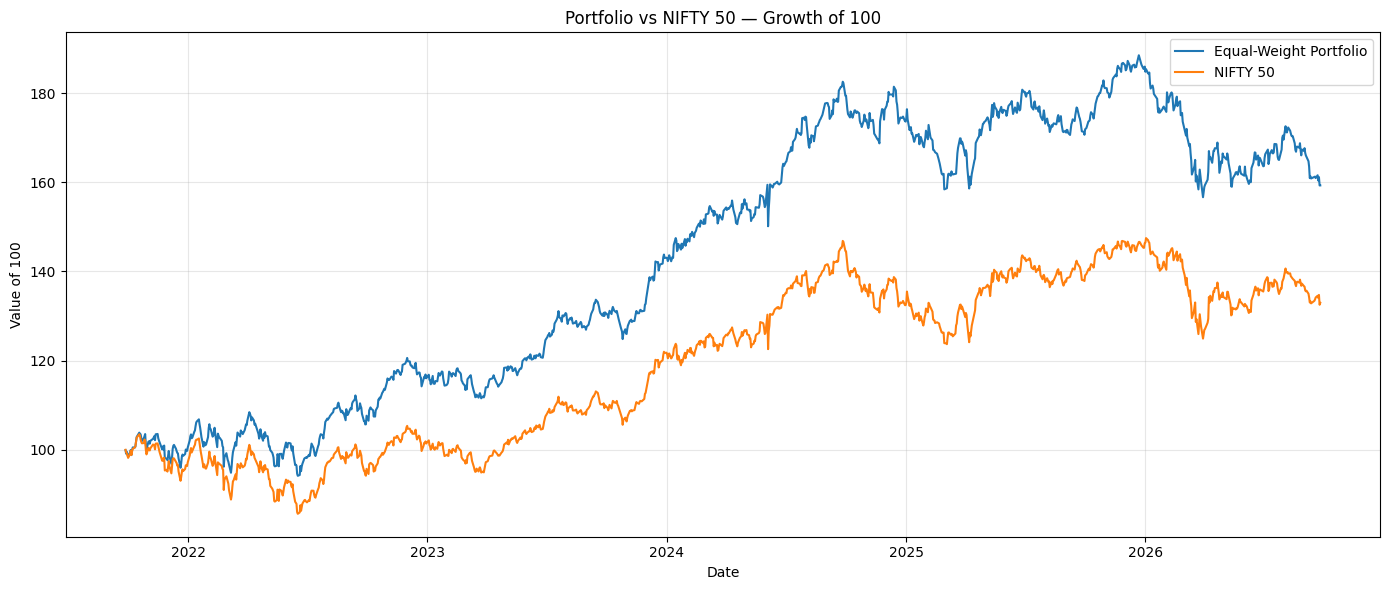

In [ ]:
plt.figure(figsize=(14, 6))

plt.plot(
    normalized_performance.index,
    normalized_performance["Portfolio"],
    label="Equal-Weight Portfolio"
)

plt.plot(
    normalized_performance.index,
    normalized_performance["NIFTY 50"],
    label="NIFTY 50"
)

plt.title("Portfolio vs NIFTY 50 — Growth of 100")
plt.xlabel("Date")
plt.ylabel("Value of 100")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
TRADING_DAYS = 252
RISK_FREE_RATE_ANNUAL = 0.0

def calculate_performance_metrics(returns):
    returns = returns.dropna()

    if len(returns) == 0:
        raise ValueError("No returns available for metric calculation.")

    cumulative_growth = (1 + returns).cumprod()

    total_return = cumulative_growth.iloc[-1] - 1

    elapsed_years = (
        (returns.index[-1] - returns.index[0]).days / 365.25
    )

    if elapsed_years <= 0:
        cagr = np.nan
    else:
        cagr = cumulative_growth.iloc[-1] ** (1 / elapsed_years) - 1

    daily_volatility = returns.std()
    annualized_volatility = daily_volatility * np.sqrt(TRADING_DAYS)

    annualized_mean_return = returns.mean() * TRADING_DAYS

    sharpe_ratio = (
        (annualized_mean_return - RISK_FREE_RATE_ANNUAL)
        / annualized_volatility
        if annualized_volatility != 0
        else np.nan
    )

    downside_returns = returns[returns < 0]

    downside_deviation = (
        np.sqrt((downside_returns ** 2).mean()) * np.sqrt(TRADING_DAYS)
        if len(downside_returns) > 0
        else np.nan
    )

    sortino_ratio = (
        (annualized_mean_return - RISK_FREE_RATE_ANNUAL)
        / downside_deviation
        if downside_deviation and downside_deviation != 0
        else np.nan
    )

    running_peak = cumulative_growth.cummax()
    drawdown = cumulative_growth / running_peak - 1
    maximum_drawdown = drawdown.min()

    return {
        "Total Return": total_return,
        "CAGR": cagr,
        "Annualized Mean Return": annualized_mean_return,
        "Annualized Volatility": annualized_volatility,
        "Sharpe Ratio": sharpe_ratio,
        "Sortino Ratio": sortino_ratio,
        "Maximum Drawdown": maximum_drawdown,
        "Number of Daily Observations": len(returns)
    }

In [ ]:
portfolio_metrics = calculate_performance_metrics(portfolio_returns)
benchmark_metrics = calculate_performance_metrics(benchmark_returns)

performance_summary = pd.DataFrame({
    "Portfolio": portfolio_metrics,
    "NIFTY 50": benchmark_metrics
})

display(performance_summary)

,Portfolio,NIFTY 50
Total Return,0.5928,0.3297
CAGR,0.0977,0.0587
Annualized Mean Return,0.1044,0.0679
Annualized Volatility,0.1351,0.1380
Sharpe Ratio,0.7730,0.4918
Sortino Ratio,0.7706,0.4763
Maximum Drawdown,-0.1689,-0.1723
Number of Daily Observations,"1,231.0000","1,231.0000"


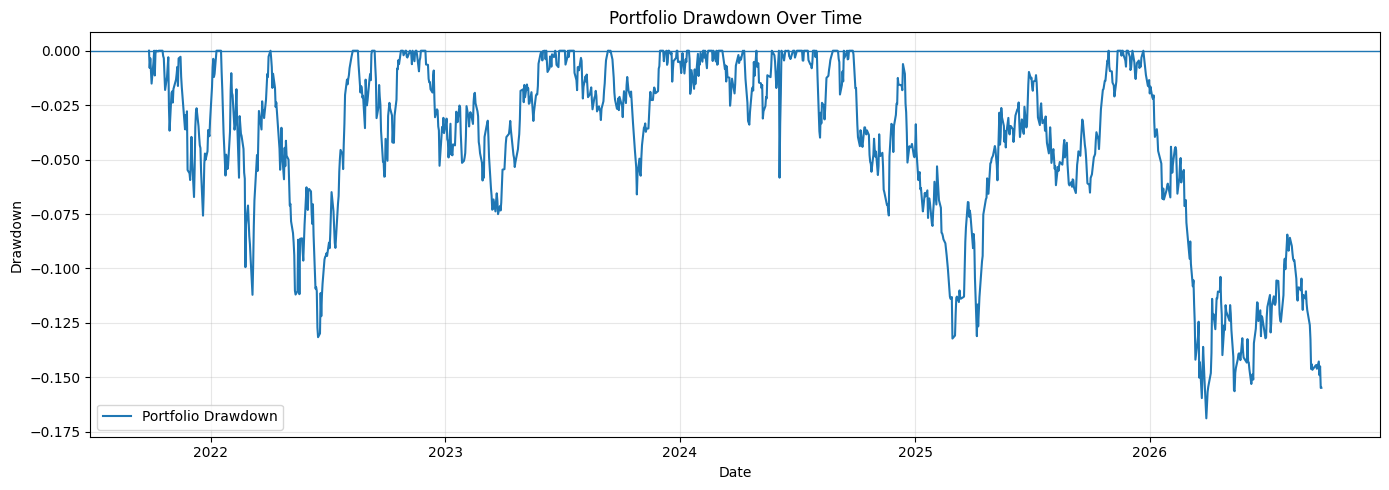

Maximum drawdown: -0.16885661521687945


In [ ]:
portfolio_growth = (1 + portfolio_returns).cumprod()

portfolio_running_peak = portfolio_growth.cummax()

portfolio_drawdown = (
    portfolio_growth / portfolio_running_peak
) - 1

plt.figure(figsize=(14, 5))

plt.plot(
    portfolio_drawdown.index,
    portfolio_drawdown,
    label="Portfolio Drawdown"
)

plt.axhline(0, linewidth=1)

plt.title("Portfolio Drawdown Over Time")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Maximum drawdown:", portfolio_drawdown.min())

In [ ]:
daily_covariance = stock_returns.cov()

annualized_covariance = daily_covariance * TRADING_DAYS

portfolio_variance_annual = (
    weights.T @ annualized_covariance @ weights
)

portfolio_volatility_annual = np.sqrt(portfolio_variance_annual)

print("Annualized portfolio variance:", portfolio_variance_annual)
print("Annualized portfolio volatility:", portfolio_volatility_annual)

Annualized portfolio variance: 0.018255936793591866
Annualized portfolio volatility: 0.13511453213326782


In [ ]:
cov_matrix = annualized_covariance.loc[
    portfolio_stocks,
    portfolio_stocks
]

weight_vector = weights.loc[portfolio_stocks].values

portfolio_vol = np.sqrt(
    weight_vector.T @ cov_matrix.values @ weight_vector
)

marginal_contribution = (
    cov_matrix.values @ weight_vector
) / portfolio_vol

component_contribution = (
    weight_vector * marginal_contribution
)

risk_contribution = pd.Series(
    component_contribution,
    index=portfolio_stocks,
    name="Risk Contribution"
)

risk_contribution_percentage = (
    risk_contribution / portfolio_vol
).rename("Share of Portfolio Volatility")

risk_contribution_table = pd.concat(
    [risk_contribution, risk_contribution_percentage],
    axis=1
).sort_values("Share of Portfolio Volatility", ascending=False)

display(risk_contribution_table)

print("Sum of component contributions:", risk_contribution.sum())
print("Portfolio volatility:", portfolio_vol)

,Risk Contribution,Share of Portfolio Volatility
LT.NS,0.0169,0.1254
SBIN.NS,0.0160,0.1187
INFY.NS,0.0160,0.1186
RELIANCE.NS,0.0148,0.1092
TCS.NS,0.0136,0.1007
HDFCBANK.NS,0.0132,0.0976
ICICIBANK.NS,0.0131,0.0969
BHARTIARTL.NS,0.0121,0.0895
ITC.NS,0.0101,0.0746
SUNPHARMA.NS,0.0093,0.0688


Sum of component contributions: 0.13511453213326785
Portfolio volatility: 0.13511453213326782


In [ ]:
weights.to_csv("portfolio_weights.csv")
returns_comparison.to_csv("portfolio_and_benchmark_returns.csv")
performance_summary.to_csv("performance_summary.csv")
daily_covariance.to_csv("daily_covariance_matrix.csv")
risk_contribution_table.to_csv("risk_contribution.csv")
portfolio_drawdown.to_csv("portfolio_drawdown.csv")

print("Day 3 outputs saved.")

Day 3 outputs saved.


In [ ]:
CONFIDENCE_LEVELS = [0.95, 0.99]

# Illustrative portfolio value, not a claim about actual invested capital.
PORTFOLIO_VALUE = 1_000_000

print("Confidence levels:", CONFIDENCE_LEVELS)
print("Illustrative portfolio value: ₹", PORTFOLIO_VALUE)

Confidence levels: [0.95, 0.99]
Illustrative portfolio value: ₹ 1000000


In [ ]:
def historical_var(returns, confidence_level):
    returns = returns.dropna()

    lower_tail_quantile = returns.quantile(1 - confidence_level)

    return -lower_tail_quantile

historical_var_results = {}

for confidence in CONFIDENCE_LEVELS:
    historical_var_results[confidence] = historical_var(
        portfolio_returns,
        confidence
    )

historical_var_table = pd.DataFrame.from_dict(
    historical_var_results,
    orient="index",
    columns=["Historical VaR (Return)"]
)

historical_var_table.index.name = "Confidence Level"

historical_var_table["Historical VaR (₹)"] = (
    historical_var_table["Historical VaR (Return)"]
    * PORTFOLIO_VALUE
)

display(historical_var_table)

,Historical VaR (Return),Historical VaR (₹)
Confidence Level,,
0.9500,0.0129,"12,937.6310"
0.9900,0.0216,"21,647.1394"


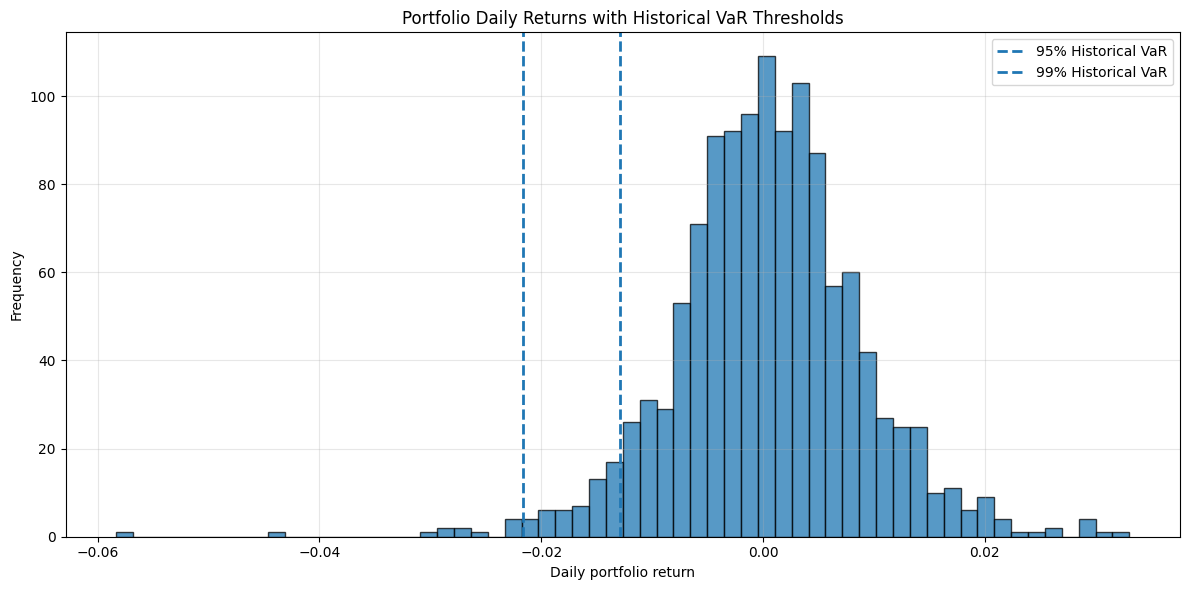

In [ ]:
plt.figure(figsize=(12, 6))

plt.hist(
    portfolio_returns.dropna(),
    bins=60,
    alpha=0.75,
    edgecolor="black"
)

for confidence, var_value in historical_var_results.items():
    plt.axvline(
        -var_value,
        linestyle="--",
        linewidth=2,
        label=f"{int(confidence * 100)}% Historical VaR"
    )

plt.title("Portfolio Daily Returns with Historical VaR Thresholds")
plt.xlabel("Daily portfolio return")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
from scipy.stats import norm

def parametric_var_normal(returns, confidence_level):
    returns = returns.dropna()

    mean_return = returns.mean()
    daily_std = returns.std()

    lower_tail_z = norm.ppf(1 - confidence_level)

    estimated_lower_return = (
        mean_return + lower_tail_z * daily_std
    )

    return -estimated_lower_return

In [ ]:
parametric_var_results = {}

for confidence in CONFIDENCE_LEVELS:
    parametric_var_results[confidence] = parametric_var_normal(
        portfolio_returns,
        confidence
    )

parametric_var_table = pd.DataFrame.from_dict(
    parametric_var_results,
    orient="index",
    columns=["Parametric VaR (Return)"]
)

parametric_var_table.index.name = "Confidence Level"

parametric_var_table["Parametric VaR (₹)"] = (
    parametric_var_table["Parametric VaR (Return)"]
    * PORTFOLIO_VALUE
)

display(parametric_var_table)

,Parametric VaR (Return),Parametric VaR (₹)
Confidence Level,,
0.9500,0.0136,"13,585.5493"
0.9900,0.0194,"19,386.0300"


In [ ]:
var_comparison = pd.DataFrame({
    "Historical VaR": historical_var_results,
    "Parametric VaR": parametric_var_results
})

var_comparison.index.name = "Confidence Level"

var_comparison["Historical VaR (₹)"] = (
    var_comparison["Historical VaR"] * PORTFOLIO_VALUE
)

var_comparison["Parametric VaR (₹)"] = (
    var_comparison["Parametric VaR"] * PORTFOLIO_VALUE
)

display(var_comparison)

,Historical VaR,Parametric VaR,Historical VaR (₹),Parametric VaR (₹)
Confidence Level,,,,
0.9500,0.0129,0.0136,"12,937.6310","13,585.5493"
0.9900,0.0216,0.0194,"21,647.1394","19,386.0300"


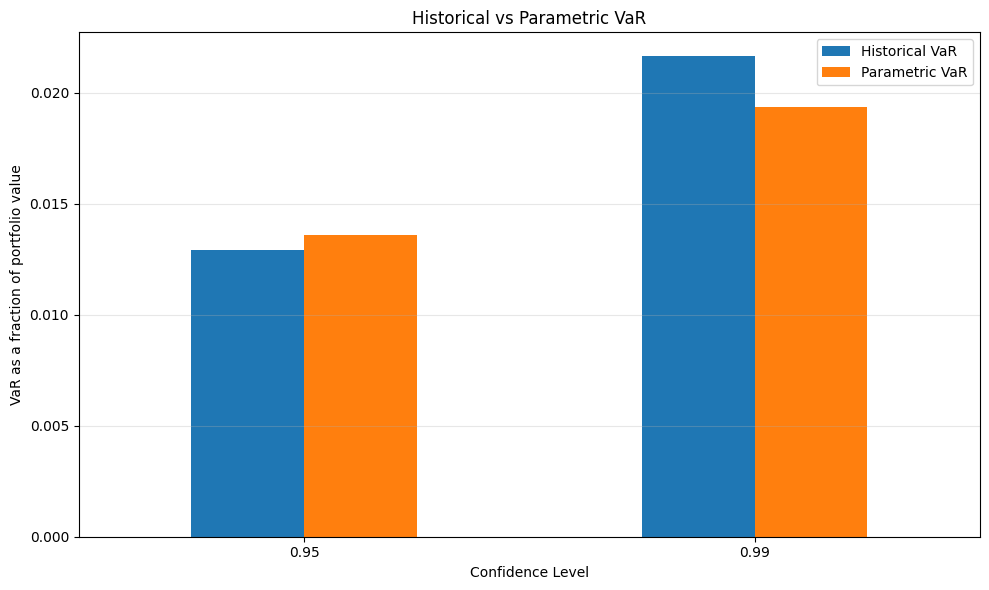

In [ ]:
plot_data = var_comparison[
    ["Historical VaR", "Parametric VaR"]
]

plot_data.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Historical vs Parametric VaR")
plt.xlabel("Confidence Level")
plt.ylabel("VaR as a fraction of portfolio value")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
var_summary = pd.DataFrame(index=CONFIDENCE_LEVELS)

var_summary.index.name = "Confidence Level"

var_summary["Historical VaR (%)"] = [
    historical_var_results[c] * 100
    for c in CONFIDENCE_LEVELS
]

var_summary["Parametric VaR (%)"] = [
    parametric_var_results[c] * 100
    for c in CONFIDENCE_LEVELS
]

var_summary["Historical VaR (₹)"] = [
    historical_var_results[c] * PORTFOLIO_VALUE
    for c in CONFIDENCE_LEVELS
]

var_summary["Parametric VaR (₹)"] = [
    parametric_var_results[c] * PORTFOLIO_VALUE
    for c in CONFIDENCE_LEVELS
]

display(var_summary.round(2))

,Historical VaR (%),Parametric VaR (%),Historical VaR (₹),Parametric VaR (₹)
Confidence Level,,,,
0.9500,1.2900,1.3600,"12,937.6300","13,585.5500"
0.9900,2.1600,1.9400,"21,647.1400","19,386.0300"


In [ ]:
historical_var_table.to_csv("historical_var_results.csv")
parametric_var_table.to_csv("parametric_var_results.csv")
var_comparison.to_csv("var_comparison.csv")
var_summary.to_csv("var_summary.csv")

print("Day 4 outputs saved.")

Day 4 outputs saved.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Number of hypothetical daily returns to generate
NUM_SIMULATIONS = 100_000

# Fixed seed makes results reproducible when rerunning this cell
RANDOM_SEED = 42

rng = np.random.default_rng(RANDOM_SEED)

# Historical portfolio return estimates
historical_mean = portfolio_returns.dropna().mean()
historical_std = portfolio_returns.dropna().std()

print(f"Historical mean daily return: {historical_mean:.6f}")
print(f"Historical daily standard deviation: {historical_std:.6f}")
print(f"Number of simulations: {NUM_SIMULATIONS:,}")

Historical mean daily return: 0.000414
Historical daily standard deviation: 0.008511
Number of simulations: 100,000


In [ ]:
simulated_returns = rng.normal(
    loc=historical_mean,
    scale=historical_std,
    size=NUM_SIMULATIONS
)

simulated_returns = pd.Series(
    simulated_returns,
    name="Simulated Daily Return"
)

print("Simulated return count:", len(simulated_returns))
display(simulated_returns.head())

Simulated return count: 100000


,Simulated Daily Return
0,0.0030
1,-0.0084
2,0.0068
3,0.0084
4,-0.0162


In [ ]:
rng.normal(loc=historical_mean, scale=historical_std, size=NUM_SIMULATIONS)

array([-0.01298759,  0.02076426,  0.01570361, ...,  0.00590017,
        0.01008033,  0.00270408])

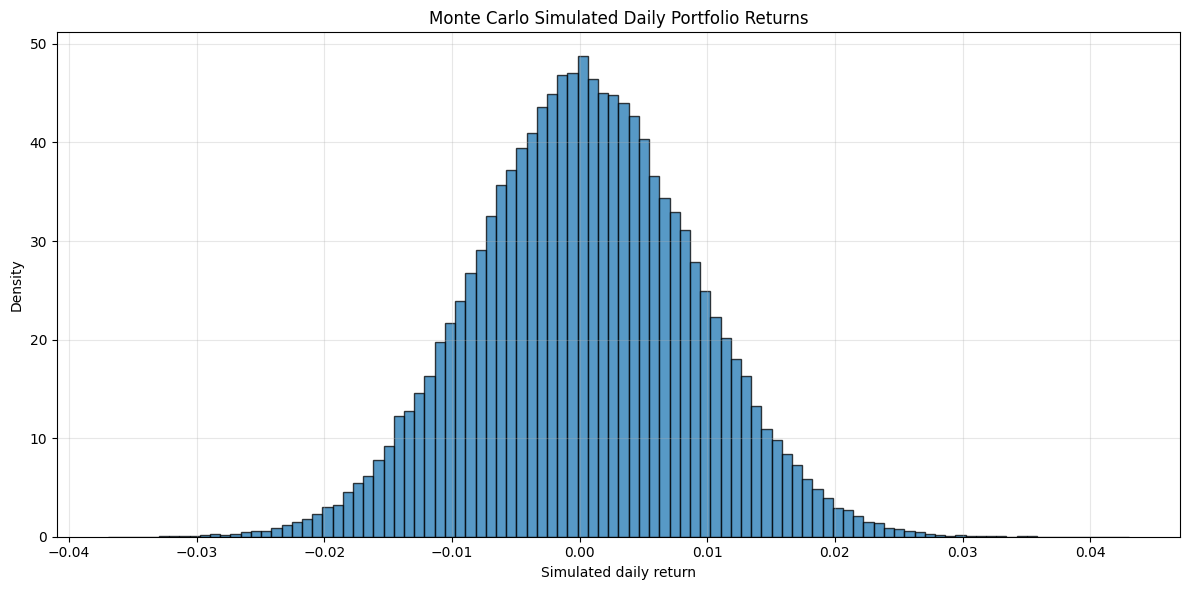

In [ ]:
plt.figure(figsize=(12, 6))

plt.hist(
    simulated_returns,
    bins=100,
    density=True,
    alpha=0.75,
    edgecolor="black"
)

plt.title("Monte Carlo Simulated Daily Portfolio Returns")
plt.xlabel("Simulated daily return")
plt.ylabel("Density")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
def monte_carlo_var(simulated_returns, confidence_level):
    """
    Estimate one-day VaR from simulated returns.
    Returns VaR as a positive loss fraction.
    """
    lower_return_quantile = simulated_returns.quantile(
        1 - confidence_level
    )

    return -lower_return_quantile


monte_carlo_var_results = {}

for confidence in CONFIDENCE_LEVELS:
    monte_carlo_var_results[confidence] = monte_carlo_var(
        simulated_returns,
        confidence
    )

monte_carlo_var_table = pd.DataFrame.from_dict(
    monte_carlo_var_results,
    orient="index",
    columns=["Monte Carlo VaR (Return)"]
)

monte_carlo_var_table.index.name = "Confidence Level"

monte_carlo_var_table["Monte Carlo VaR (₹)"] = (
    monte_carlo_var_table["Monte Carlo VaR (Return)"]
    * PORTFOLIO_VALUE
)

display(monte_carlo_var_table)

,Monte Carlo VaR (Return),Monte Carlo VaR (₹)
Confidence Level,,
0.9500,0.0137,"13,700.3934"
0.9900,0.0195,"19,532.1167"


In [ ]:
def monte_carlo_cvar(simulated_returns, confidence_level):
    """
    Estimate one-day CVaR / Expected Shortfall from simulated returns.

    Loss is defined as negative return.
    CVaR is the average loss at or beyond the VaR threshold.
    """
    losses = -simulated_returns

    var_loss = losses.quantile(confidence_level)

    tail_losses = losses[losses >= var_loss]

    cvar_loss = tail_losses.mean()

    return cvar_loss


monte_carlo_cvar_results = {}

for confidence in CONFIDENCE_LEVELS:
    monte_carlo_cvar_results[confidence] = monte_carlo_cvar(
        simulated_returns,
        confidence
    )

monte_carlo_cvar_table = pd.DataFrame.from_dict(
    monte_carlo_cvar_results,
    orient="index",
    columns=["Monte Carlo CVaR (Return)"]
)

monte_carlo_cvar_table.index.name = "Confidence Level"

monte_carlo_cvar_table["Monte Carlo CVaR (₹)"] = (
    monte_carlo_cvar_table["Monte Carlo CVaR (Return)"]
    * PORTFOLIO_VALUE
)

display(monte_carlo_cvar_table)

,Monte Carlo CVaR (Return),Monte Carlo CVaR (₹)
Confidence Level,,
0.9500,0.0172,"17,233.9777"
0.9900,0.0225,"22,459.9912"


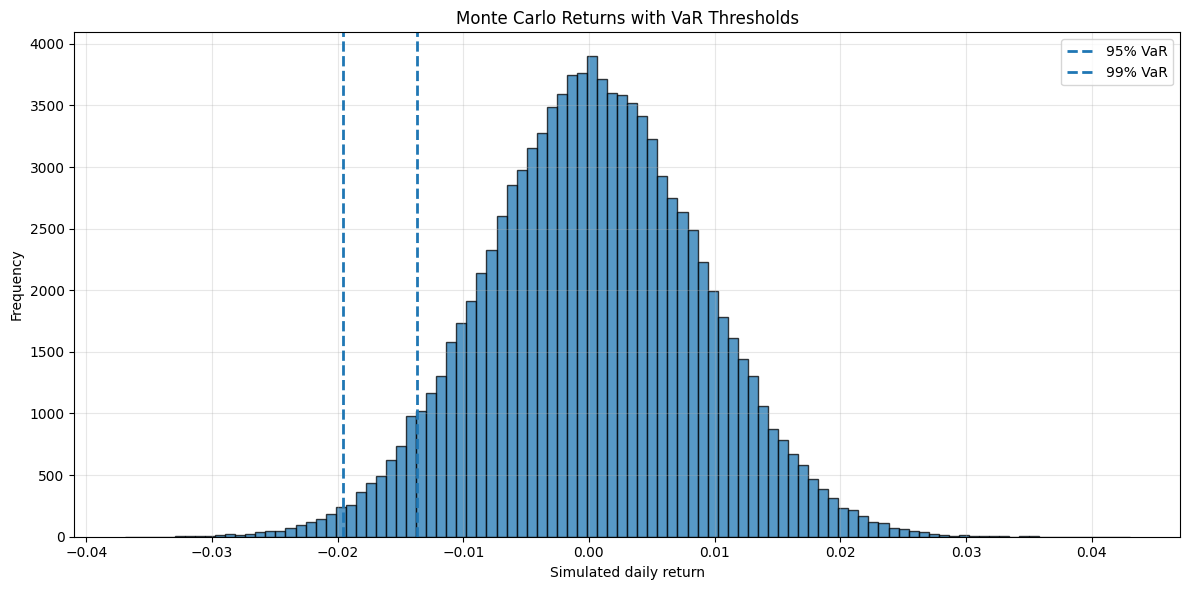

In [ ]:
plt.figure(figsize=(12, 6))

plt.hist(
    simulated_returns,
    bins=100,
    alpha=0.75,
    edgecolor="black"
)

for confidence, var_value in monte_carlo_var_results.items():
    plt.axvline(
        -var_value,
        linestyle="--",
        linewidth=2,
        label=f"{int(confidence * 100)}% VaR"
    )

plt.title("Monte Carlo Returns with VaR Thresholds")
plt.xlabel("Simulated daily return")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
var_methods_comparison = pd.DataFrame(
    {
        "Historical VaR": historical_var_results,
        "Parametric VaR": parametric_var_results,
        "Monte Carlo VaR": monte_carlo_var_results
    }
)

var_methods_comparison.index.name = "Confidence Level"

display(var_methods_comparison)

,Historical VaR,Parametric VaR,Monte Carlo VaR
Confidence Level,,,
0.9500,0.0129,0.0136,0.0137
0.9900,0.0216,0.0194,0.0195


In [ ]:
var_methods_rupees = var_methods_comparison * PORTFOLIO_VALUE

var_methods_rupees.columns = [
    f"{column} (₹)"
    for column in var_methods_rupees.columns
]

display(var_methods_rupees.round(2))

,Historical VaR (₹),Parametric VaR (₹),Monte Carlo VaR (₹)
Confidence Level,,,
0.9500,"12,937.6300","13,585.5500","13,700.3900"
0.9900,"21,647.1400","19,386.0300","19,532.1200"


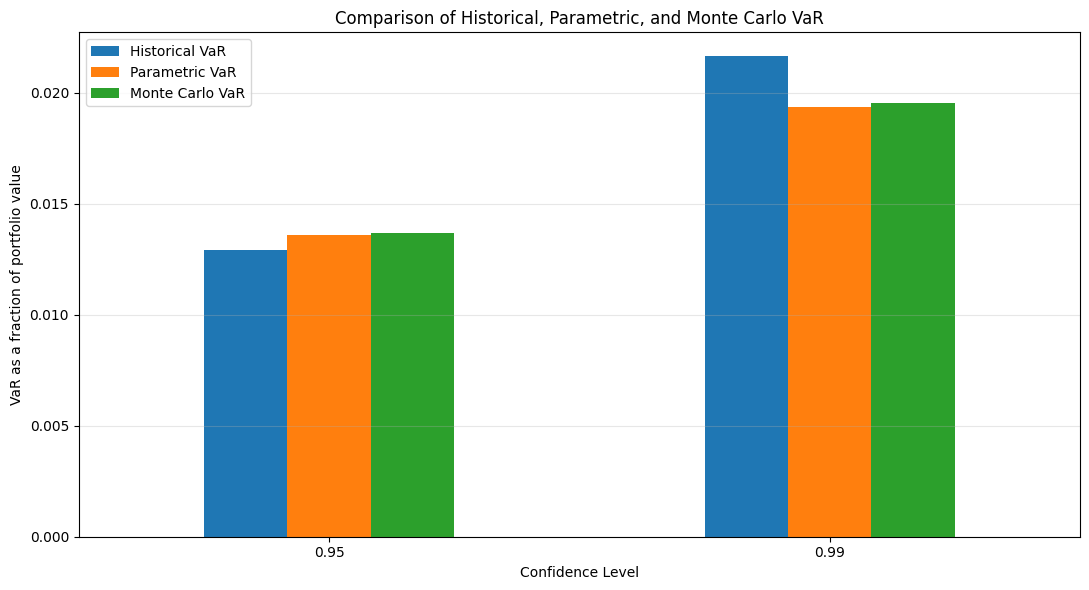

In [ ]:
var_methods_comparison.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title("Comparison of Historical, Parametric, and Monte Carlo VaR")
plt.xlabel("Confidence Level")
plt.ylabel("VaR as a fraction of portfolio value")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
risk_summary_day5 = pd.DataFrame(index=CONFIDENCE_LEVELS)

risk_summary_day5.index.name = "Confidence Level"

risk_summary_day5["Historical VaR"] = [
    historical_var_results[c]
    for c in CONFIDENCE_LEVELS
]

risk_summary_day5["Parametric VaR"] = [
    parametric_var_results[c]
    for c in CONFIDENCE_LEVELS
]

risk_summary_day5["Monte Carlo VaR"] = [
    monte_carlo_var_results[c]
    for c in CONFIDENCE_LEVELS
]

risk_summary_day5["Monte Carlo CVaR"] = [
    monte_carlo_cvar_results[c]
    for c in CONFIDENCE_LEVELS
]

display(risk_summary_day5)

,Historical VaR,Parametric VaR,Monte Carlo VaR,Monte Carlo CVaR
Confidence Level,,,,
0.9500,0.0129,0.0136,0.0137,0.0172
0.9900,0.0216,0.0194,0.0195,0.0225


In [ ]:
risk_summary_day5_rupees = risk_summary_day5 * PORTFOLIO_VALUE

display(risk_summary_day5_rupees.round(2))

,Historical VaR,Parametric VaR,Monte Carlo VaR,Monte Carlo CVaR
Confidence Level,,,,
0.9500,"12,937.6300","13,585.5500","13,700.3900","17,233.9800"
0.9900,"21,647.1400","19,386.0300","19,532.1200","22,459.9900"


In [ ]:
simulated_returns.to_frame().to_csv(
    "monte_carlo_simulated_returns.csv",
    index=False
)

monte_carlo_var_table.to_csv(
    "monte_carlo_var_results.csv"
)

monte_carlo_cvar_table.to_csv(
    "monte_carlo_cvar_results.csv"
)

var_methods_comparison.to_csv(
    "var_methods_comparison.csv"
)

risk_summary_day5.to_csv(
    "day5_risk_summary.csv"
)

print("Day 5 outputs saved.")

Day 5 outputs saved.


In [ ]:
# Portfolio value used for illustrative monetary loss calculations
PORTFOLIO_VALUE = 1_000_000  # ₹10 lakh

# Confirm the portfolio assets and weights are aligned
portfolio_stocks = list(weights.index)

print("Portfolio stocks:", portfolio_stocks)
print("Weights sum:", weights.sum())

Portfolio stocks: ['RELIANCE.NS', 'TCS.NS', 'INFY.NS', 'HDFCBANK.NS', 'ICICIBANK.NS', 'SBIN.NS', 'ITC.NS', 'LT.NS', 'BHARTIARTL.NS', 'SUNPHARMA.NS']
Weights sum: 1.0


In [ ]:
# Hypothetical stock-level returns for each scenario.
# Any stock not explicitly listed in a scenario receives a 0% shock.

stress_scenarios = {
    "Broad Market Shock": {
        stock: -0.20 for stock in portfolio_stocks
    },

    "Banking Sector Shock": {
        "HDFCBANK.NS": -0.25,
        "ICICIBANK.NS": -0.25,
        "SBIN.NS": -0.25
    },

    "IT Sector Shock": {
        "TCS.NS": -0.25,
        "INFY.NS": -0.25
    },

    "Combined Market and Sector Shock": {
        **{stock: -0.15 for stock in portfolio_stocks},
        "HDFCBANK.NS": -0.25,
        "ICICIBANK.NS": -0.25,
        "SBIN.NS": -0.25,
        "TCS.NS": -0.20,
        "INFY.NS": -0.20
    }
}

In [ ]:
import pandas as pd
import numpy as np

stress_returns = pd.DataFrame(
    stress_scenarios
).reindex(index=portfolio_stocks).fillna(0)

# Each column is a scenario; each row is a stock.
# Portfolio scenario return = sum(stock weight × stock scenario return)
scenario_portfolio_returns = stress_returns.T.dot(weights)

stress_results = pd.DataFrame({
    "Portfolio Return": scenario_portfolio_returns,
    "Estimated P&L (₹)": scenario_portfolio_returns * PORTFOLIO_VALUE
})

stress_results["Estimated Loss (₹)"] = (
    -stress_results["Estimated P&L (₹)"]
)

stress_results

,Portfolio Return,Estimated P&L (₹),Estimated Loss (₹)
Broad Market Shock,-0.2000,"-200,000.0000","200,000.0000"
Banking Sector Shock,-0.0750,"-75,000.0000","75,000.0000"
IT Sector Shock,-0.0500,"-50,000.0000","50,000.0000"
Combined Market and Sector Shock,-0.1900,"-190,000.0000","190,000.0000"


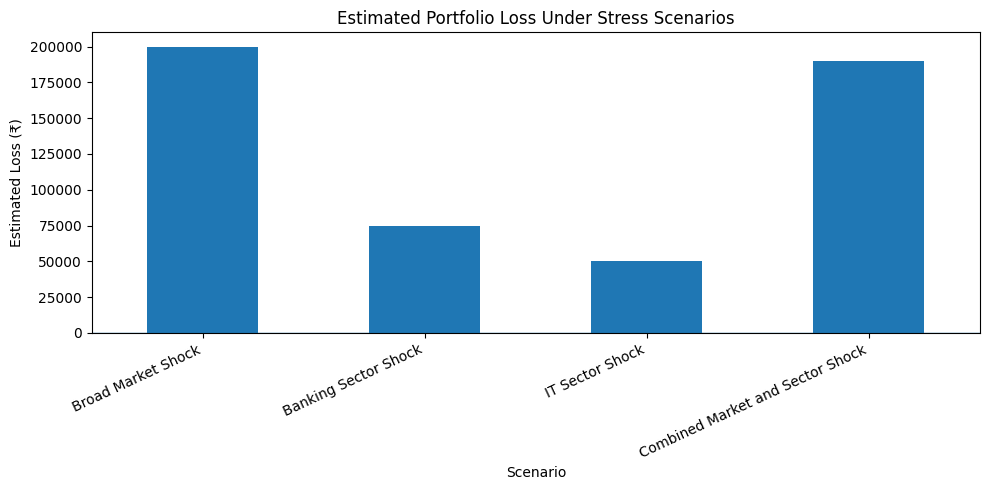

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

stress_results["Estimated Loss (₹)"].plot(
    kind="bar",
    title="Estimated Portfolio Loss Under Stress Scenarios",
    ylabel="Estimated Loss (₹)",
    xlabel="Scenario"
)

plt.axhline(0, linewidth=1)
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
# Stock-level P&L contribution = weight × scenario return × portfolio value
stock_scenario_pnl = stress_returns.mul(weights, axis=0) * PORTFOLIO_VALUE

# Convert P&L contributions into loss contributions
stock_scenario_loss = -stock_scenario_pnl

stock_scenario_loss

,Broad Market Shock,Banking Sector Shock,IT Sector Shock,Combined Market and Sector Shock
RELIANCE.NS,"20,000.0000",-0.0000,-0.0000,"15,000.0000"
TCS.NS,"20,000.0000",-0.0000,"25,000.0000","20,000.0000"
INFY.NS,"20,000.0000",-0.0000,"25,000.0000","20,000.0000"
HDFCBANK.NS,"20,000.0000","25,000.0000",-0.0000,"25,000.0000"
ICICIBANK.NS,"20,000.0000","25,000.0000",-0.0000,"25,000.0000"
SBIN.NS,"20,000.0000","25,000.0000",-0.0000,"25,000.0000"
ITC.NS,"20,000.0000",-0.0000,-0.0000,"15,000.0000"
LT.NS,"20,000.0000",-0.0000,-0.0000,"15,000.0000"
BHARTIARTL.NS,"20,000.0000",-0.0000,-0.0000,"15,000.0000"
SUNPHARMA.NS,"20,000.0000",-0.0000,-0.0000,"15,000.0000"


<Figure size 1200x600 with 0 Axes>

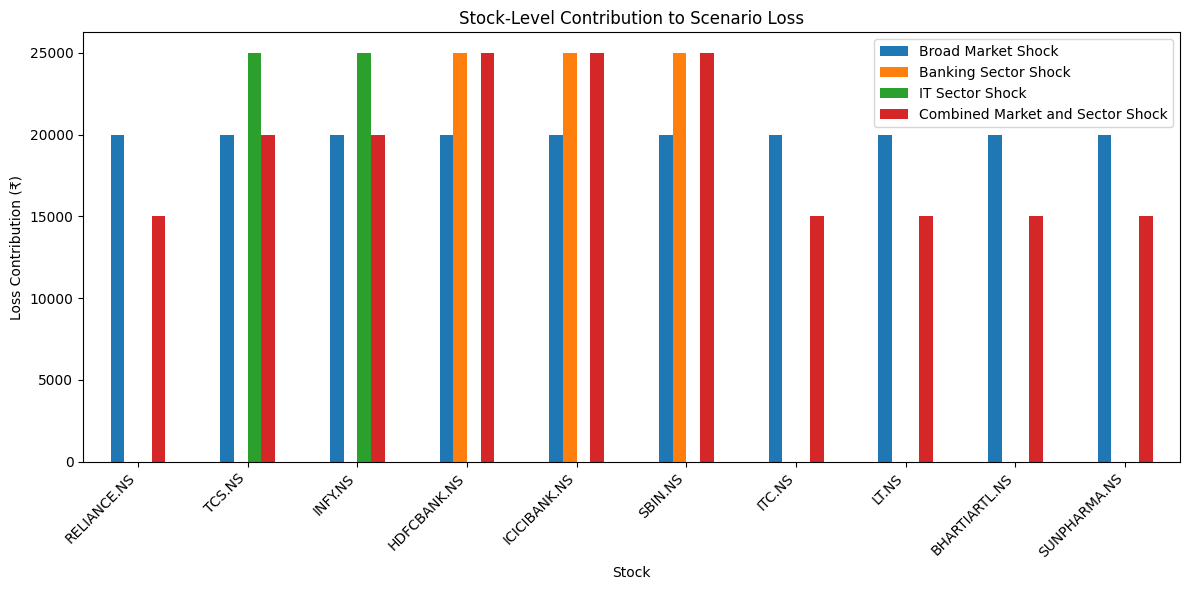

In [ ]:
plt.figure(figsize=(12, 6))

stock_scenario_loss.plot(
    kind="bar",
    figsize=(12, 6),
    title="Stock-Level Contribution to Scenario Loss",
    ylabel="Loss Contribution (₹)",
    xlabel="Stock"
)

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

<Figure size 1200x600 with 0 Axes>

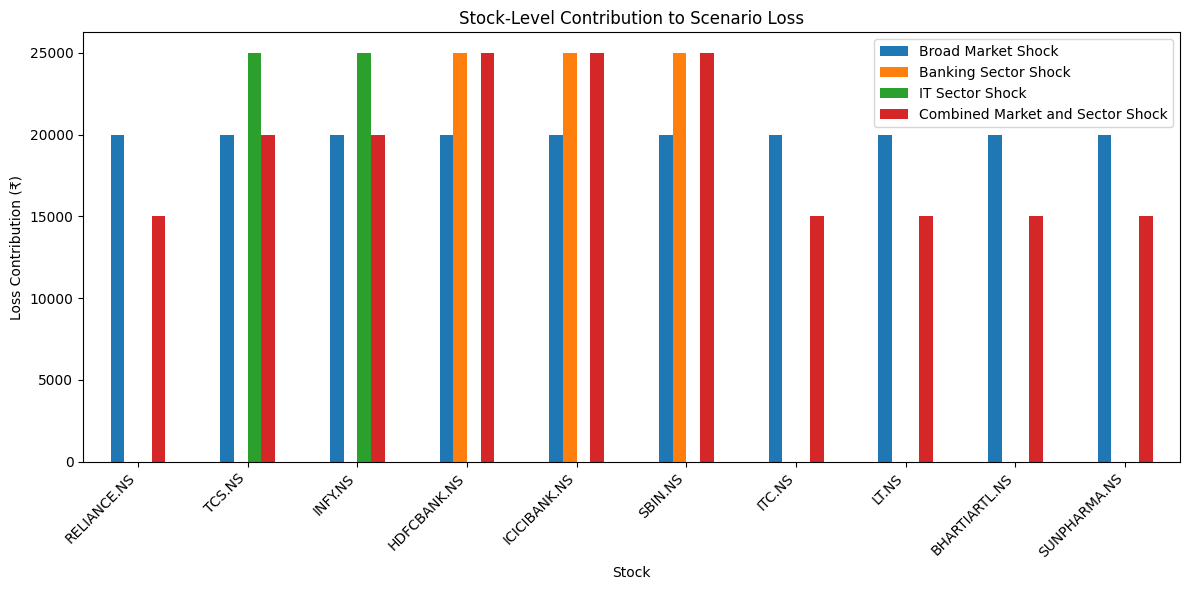

In [ ]:
plt.figure(figsize=(12, 6))

stock_scenario_loss.plot(
    kind="bar",
    figsize=(12, 6),
    title="Stock-Level Contribution to Scenario Loss",
    ylabel="Loss Contribution (₹)",
    xlabel="Stock"
)

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
stress_returns.to_csv("day6_stress_scenario_returns.csv")
stress_results.to_csv("day6_stress_results.csv")
stock_scenario_loss.to_csv("day6_stock_loss_contributions.csv")

print("Day 6 stress-testing outputs saved.")

Day 6 stress-testing outputs saved.


In [ ]:
WINDOW = 252
BACKTEST_CONFIDENCE_LEVELS = [0.95, 0.99]

backtest = pd.DataFrame(index=portfolio_returns.index)

# Positive values represent losses.
backtest["Actual Loss"] = -portfolio_returns

for confidence in BACKTEST_CONFIDENCE_LEVELS:
    alpha = 1 - confidence

    # Estimate the loss threshold from the previous 252 daily returns.
    # shift(1) prevents the current day's return from entering its own VaR estimate.
    rolling_var = (
        portfolio_returns
        .rolling(window=WINDOW, min_periods=WINDOW)
        .quantile(alpha)
        .shift(1)
    )

    # Convert the lower-tail return quantile into a positive loss threshold.
    backtest[f"VaR {int(confidence * 100)}%"] = -rolling_var

backtest = backtest.dropna()

backtest.head()

,Actual Loss,VaR 95%,VaR 99%
Date,,,
2022-09-30,-0.0183,0.0181,0.0273
2022-10-03,0.0105,0.0181,0.0273
2022-10-04,-0.0217,0.0181,0.0273
2022-10-06,-0.0062,0.0181,0.0273
2022-10-07,0.0026,0.0181,0.0273


In [ ]:
for confidence in BACKTEST_CONFIDENCE_LEVELS:
    var_column = f"VaR {int(confidence * 100)}%"
    breach_column = f"Breach {int(confidence * 100)}%"

    backtest[breach_column] = (
        backtest["Actual Loss"] > backtest[var_column]
    )

backtest.head()

,Actual Loss,VaR 95%,VaR 99%,Breach 95%,Breach 99%
Date,,,,,
2022-09-30,-0.0183,0.0181,0.0273,False,False
2022-10-03,0.0105,0.0181,0.0273,False,False
2022-10-04,-0.0217,0.0181,0.0273,False,False
2022-10-06,-0.0062,0.0181,0.0273,False,False
2022-10-07,0.0026,0.0181,0.0273,False,False


In [ ]:
backtest_summary_rows = []

for confidence in BACKTEST_CONFIDENCE_LEVELS:
    var_column = f"VaR {int(confidence * 100)}%"
    breach_column = f"Breach {int(confidence * 100)}%"

    total_days = len(backtest)
    breach_count = int(backtest[breach_column].sum())
    observed_breach_rate = breach_count / total_days
    expected_breach_rate = 1 - confidence

    backtest_summary_rows.append({
        "Confidence Level": f"{int(confidence * 100)}%",
        "Backtest Days": total_days,
        "Breach Count": breach_count,
        "Observed Breach Rate": observed_breach_rate,
        "Expected Breach Rate": expected_breach_rate
    })

backtest_summary = pd.DataFrame(backtest_summary_rows)
backtest_summary

,Confidence Level,Backtest Days,Breach Count,Observed Breach Rate,Expected Breach Rate
0,95%,979,56,0.0572,0.0500
1,99%,979,13,0.0133,0.0100


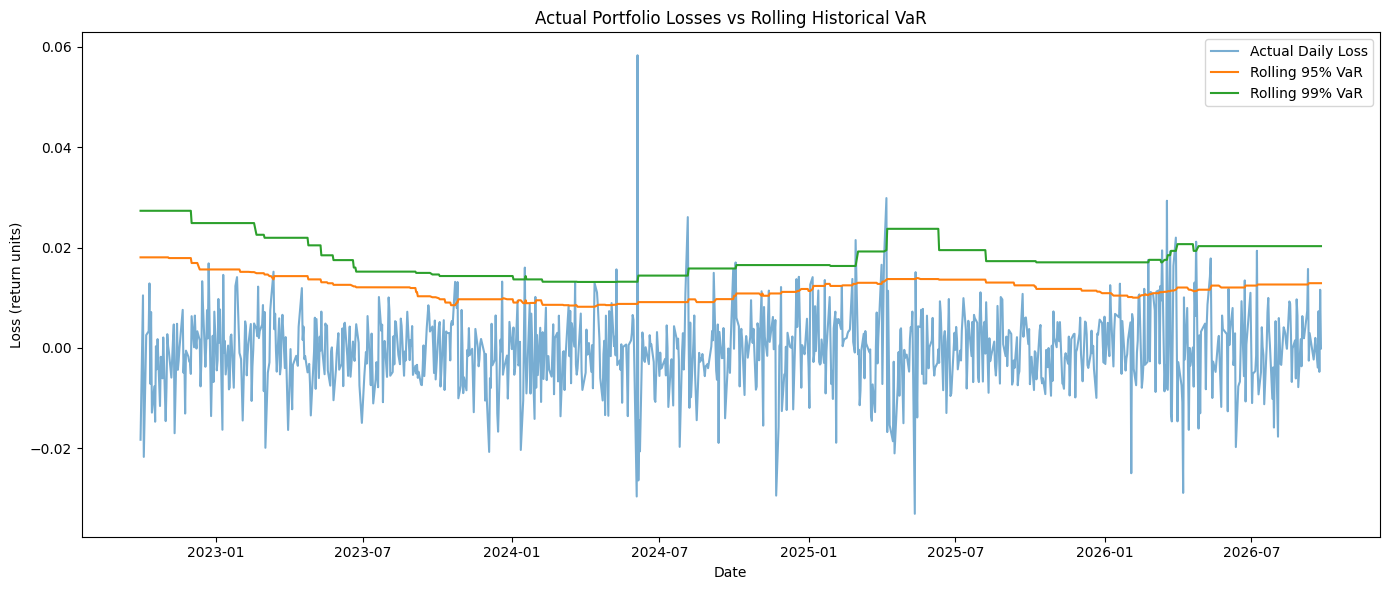

In [ ]:
plt.figure(figsize=(14, 6))

plt.plot(
    backtest.index,
    backtest["Actual Loss"],
    label="Actual Daily Loss",
    alpha=0.6
)

plt.plot(
    backtest.index,
    backtest["VaR 95%"],
    label="Rolling 95% VaR",
    linewidth=1.5
)

plt.plot(
    backtest.index,
    backtest["VaR 99%"],
    label="Rolling 99% VaR",
    linewidth=1.5
)

plt.title("Actual Portfolio Losses vs Rolling Historical VaR")
plt.xlabel("Date")
plt.ylabel("Loss (return units)")
plt.legend()
plt.tight_layout()
plt.show()

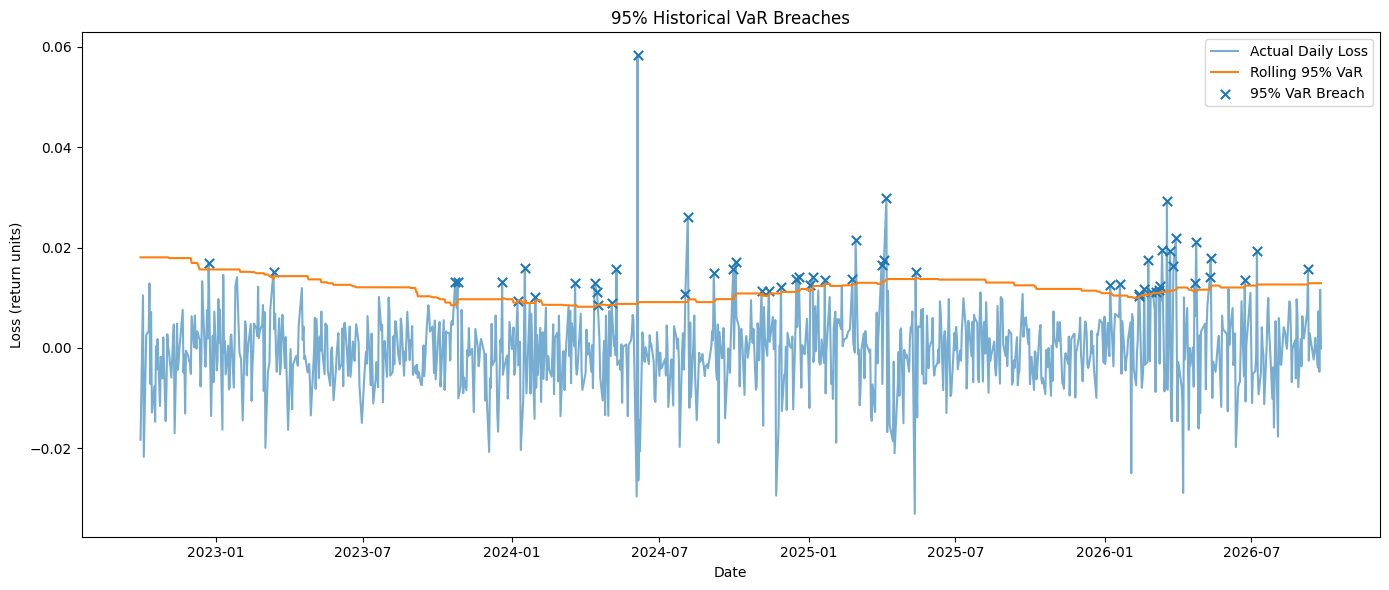

In [ ]:
breaches_95 = backtest[backtest["Breach 95%"]]

plt.figure(figsize=(14, 6))

plt.plot(
    backtest.index,
    backtest["Actual Loss"],
    label="Actual Daily Loss",
    alpha=0.6
)

plt.plot(
    backtest.index,
    backtest["VaR 95%"],
    label="Rolling 95% VaR",
    linewidth=1.5
)

plt.scatter(
    breaches_95.index,
    breaches_95["Actual Loss"],
    label="95% VaR Breach",
    marker="x",
    s=45
)

plt.title("95% Historical VaR Breaches")
plt.xlabel("Date")
plt.ylabel("Loss (return units)")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
backtest_rupee = backtest.copy()

loss_columns = [
    "Actual Loss",
    "VaR 95%",
    "VaR 99%"
]

for column in loss_columns:
    backtest_rupee[f"{column} (₹)"] = (
        backtest_rupee[column] * PORTFOLIO_VALUE
    )

backtest_rupee[
    ["Actual Loss (₹)", "VaR 95% (₹)", "VaR 99% (₹)"]
].head()

,Actual Loss (₹),VaR 95% (₹),VaR 99% (₹)
Date,,,
2022-09-30,"-18,274.9435","18,057.4561","27,333.4778"
2022-10-03,"10,486.0463","18,057.4561","27,333.4778"
2022-10-04,"-21,690.9363","18,057.4561","27,333.4778"
2022-10-06,"-6,191.6424","18,057.4561","27,333.4778"
2022-10-07,"2,572.4450","18,057.4561","27,333.4778"


In [ ]:
backtest.to_csv("day7_var_backtesting_returns.csv")
backtest_rupee.to_csv("day7_var_backtesting_rupees.csv")
backtest_summary.to_csv("day7_var_backtesting_summary.csv", index=False)

print("Day 7 backtesting outputs saved.")

Day 7 backtesting outputs saved.
